In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, mean_absolute_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

df = pd.read_csv('heart_disease_dataset.csv')
df

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1


## 1. Preprocesamiento de Datos

Antes de aplicar los modelos de aprendizaje automático, necesitamos preprocesar los datos. Esto implica:

*   **Manejo de Valores Faltantes:** La columna `Alcohol Intake` tiene valores faltantes (NaNs). Los rellenaremos con 'Unknown' para tratarlos como una categoría separada.
*   **Codificación de Características Categóricas:** Convertiremos las columnas categóricas en representaciones numéricas utilizando la codificación one-hot.

In [54]:
print("Información del DataFrame Original:")
df.info()

# Rellenar los valores faltantes en 'Alcohol Intake' con 'Unknown'
df['Alcohol Intake'] = df['Alcohol Intake'].fillna('Unknown')

# Identificar columnas categóricas (excluyendo el objetivo 'Heart Disease' por ahora)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Aplicar codificación one-hot a las columnas categóricas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nInformación del DataFrame después de la codificación One-Hot y manejo de NaNs:")
df_encoded.info()

display(df_encoded.head())

Información del DataFrame Original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease,Gender_Male,Smoking_Former,Smoking_Never,Alcohol Intake_Moderate,Alcohol Intake_Unknown,Family History_Yes,Diabetes_Yes,Obesity_Yes,Exercise Induced Angina_Yes,Chest Pain Type_Atypical Angina,Chest Pain Type_Non-anginal Pain,Chest Pain Type_Typical Angina
0,75,228,119,66,1,8,119,1,False,False,False,False,False,False,False,True,True,True,False,False
1,48,204,165,62,5,9,70,0,True,False,False,False,True,False,False,False,True,False,False,True
2,53,234,91,67,3,5,196,1,True,False,True,False,False,True,False,True,True,True,False,False
3,69,192,90,72,4,7,107,0,False,False,False,False,True,False,True,False,True,False,True,False
4,62,172,163,93,6,2,183,0,False,False,True,False,True,False,True,False,True,False,False,False


## 2. K-Vecinos Más Cercanos (KNN)


### 2.1 Clasificación KNN

Para la clasificación, prediremos `Heart Disease` (nuestra variable objetivo binaria) basándonos en otras características. KNN es sensible a la escala de las características, por lo que aplicaremos `StandardScaler`.

In [55]:
# Definir características (X) y objetivo (y) para clasificación
X_clf = df_encoded.drop('Heart Disease', axis=1)
y_clf = df_encoded['Heart Disease']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Escalar las características numéricas (importante para KNN)
scaler_clf = StandardScaler()
X_train_scaled_clf = scaler_clf.fit_transform(X_train_clf)
X_test_scaled_clf = scaler_clf.transform(X_test_clf)

# Inicializar y entrenar el Clasificador KNN
knn_classifier = KNeighborsClassifier(n_neighbors=5) # Usando 5 vecinos
knn_classifier.fit(X_train_scaled_clf, y_train_clf)

# Realizar predicciones
y_pred_clf = knn_classifier.predict(X_test_scaled_clf)

# Evaluar el modelo
print("### Resultados de Clasificación KNN ###")
print(f"Precisión: {accuracy_score(y_test_clf, y_pred_clf):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_clf, y_pred_clf))

### Resultados de Clasificación KNN ###
Precisión: 0.70

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       171
           1       0.68      0.57      0.62       129

    accuracy                           0.70       300
   macro avg       0.69      0.68      0.68       300
weighted avg       0.69      0.70      0.69       300



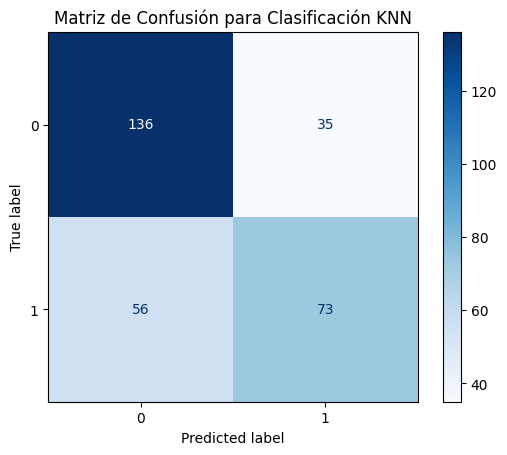

In [56]:
# Generar la matriz de confusión para KNN Clasificación
cm_knn = confusion_matrix(y_test_clf, y_pred_clf)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_classifier.classes_)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión para Clasificación KNN')
plt.show()

### 2.2 Regresión KNN

Para la regresión, intentaremos predecir `Cholesterol` como una variable objetivo continua. De nuevo, la escalada de características es importante.

In [57]:
# Definir características (X) y objetivo (y) para regresión
# Eliminamos 'Heart Disease' y el objetivo 'Cholesterol' de las características
X_reg = df_encoded.drop(['Heart Disease', 'Cholesterol'], axis=1)
y_reg = df_encoded['Cholesterol']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Escalar las características numéricas
scaler_reg = StandardScaler()
X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg)
X_test_scaled_reg = scaler_reg.transform(X_test_reg)

# Inicializar y entrenar el Regresor KNN
knn_regressor = KNeighborsRegressor(n_neighbors=5) # Usando 5 vecinos
knn_regressor.fit(X_train_scaled_reg, y_train_reg)

# Realizar predicciones
y_pred_reg = knn_regressor.predict(X_test_scaled_reg)

# Evaluar el modelo
print("### Resultados de Regresión KNN ###")
print(f"Error Absoluto Medio (MAE): {mean_absolute_error(y_test_reg, y_pred_reg):.2f}")
print(f"R-cuadrado (R2): {r2_score(y_test_reg, y_pred_reg):.2f}")

### Resultados de Regresión KNN ###
Error Absoluto Medio (MAE): 53.31
R-cuadrado (R2): -0.17


## 3. Árbol de Decisión


### 3.1 Clasificación con Árbol de Decisión

Aquí, usaremos un Árbol de Decisión para clasificar `Heart Disease`.

In [58]:
# Usaremos los mismos X_clf e y_clf definidos anteriormente
# X_train_clf, X_test_clf, y_train_clf, y_test_clf

# Inicializar y entrenar el Clasificador de Árbol de Decisión
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_clf, y_train_clf)

# Realizar predicciones
y_pred_dt_clf = dt_classifier.predict(X_test_clf)

# Evaluar el modelo
print("### Resultados de Clasificación con Árbol de Decisión ###")
print(f"Precisión: {accuracy_score(y_test_clf, y_pred_dt_clf):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_clf, y_pred_dt_clf))

### Resultados de Clasificación con Árbol de Decisión ###
Precisión: 1.00

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       171
           1       1.00      1.00      1.00       129

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



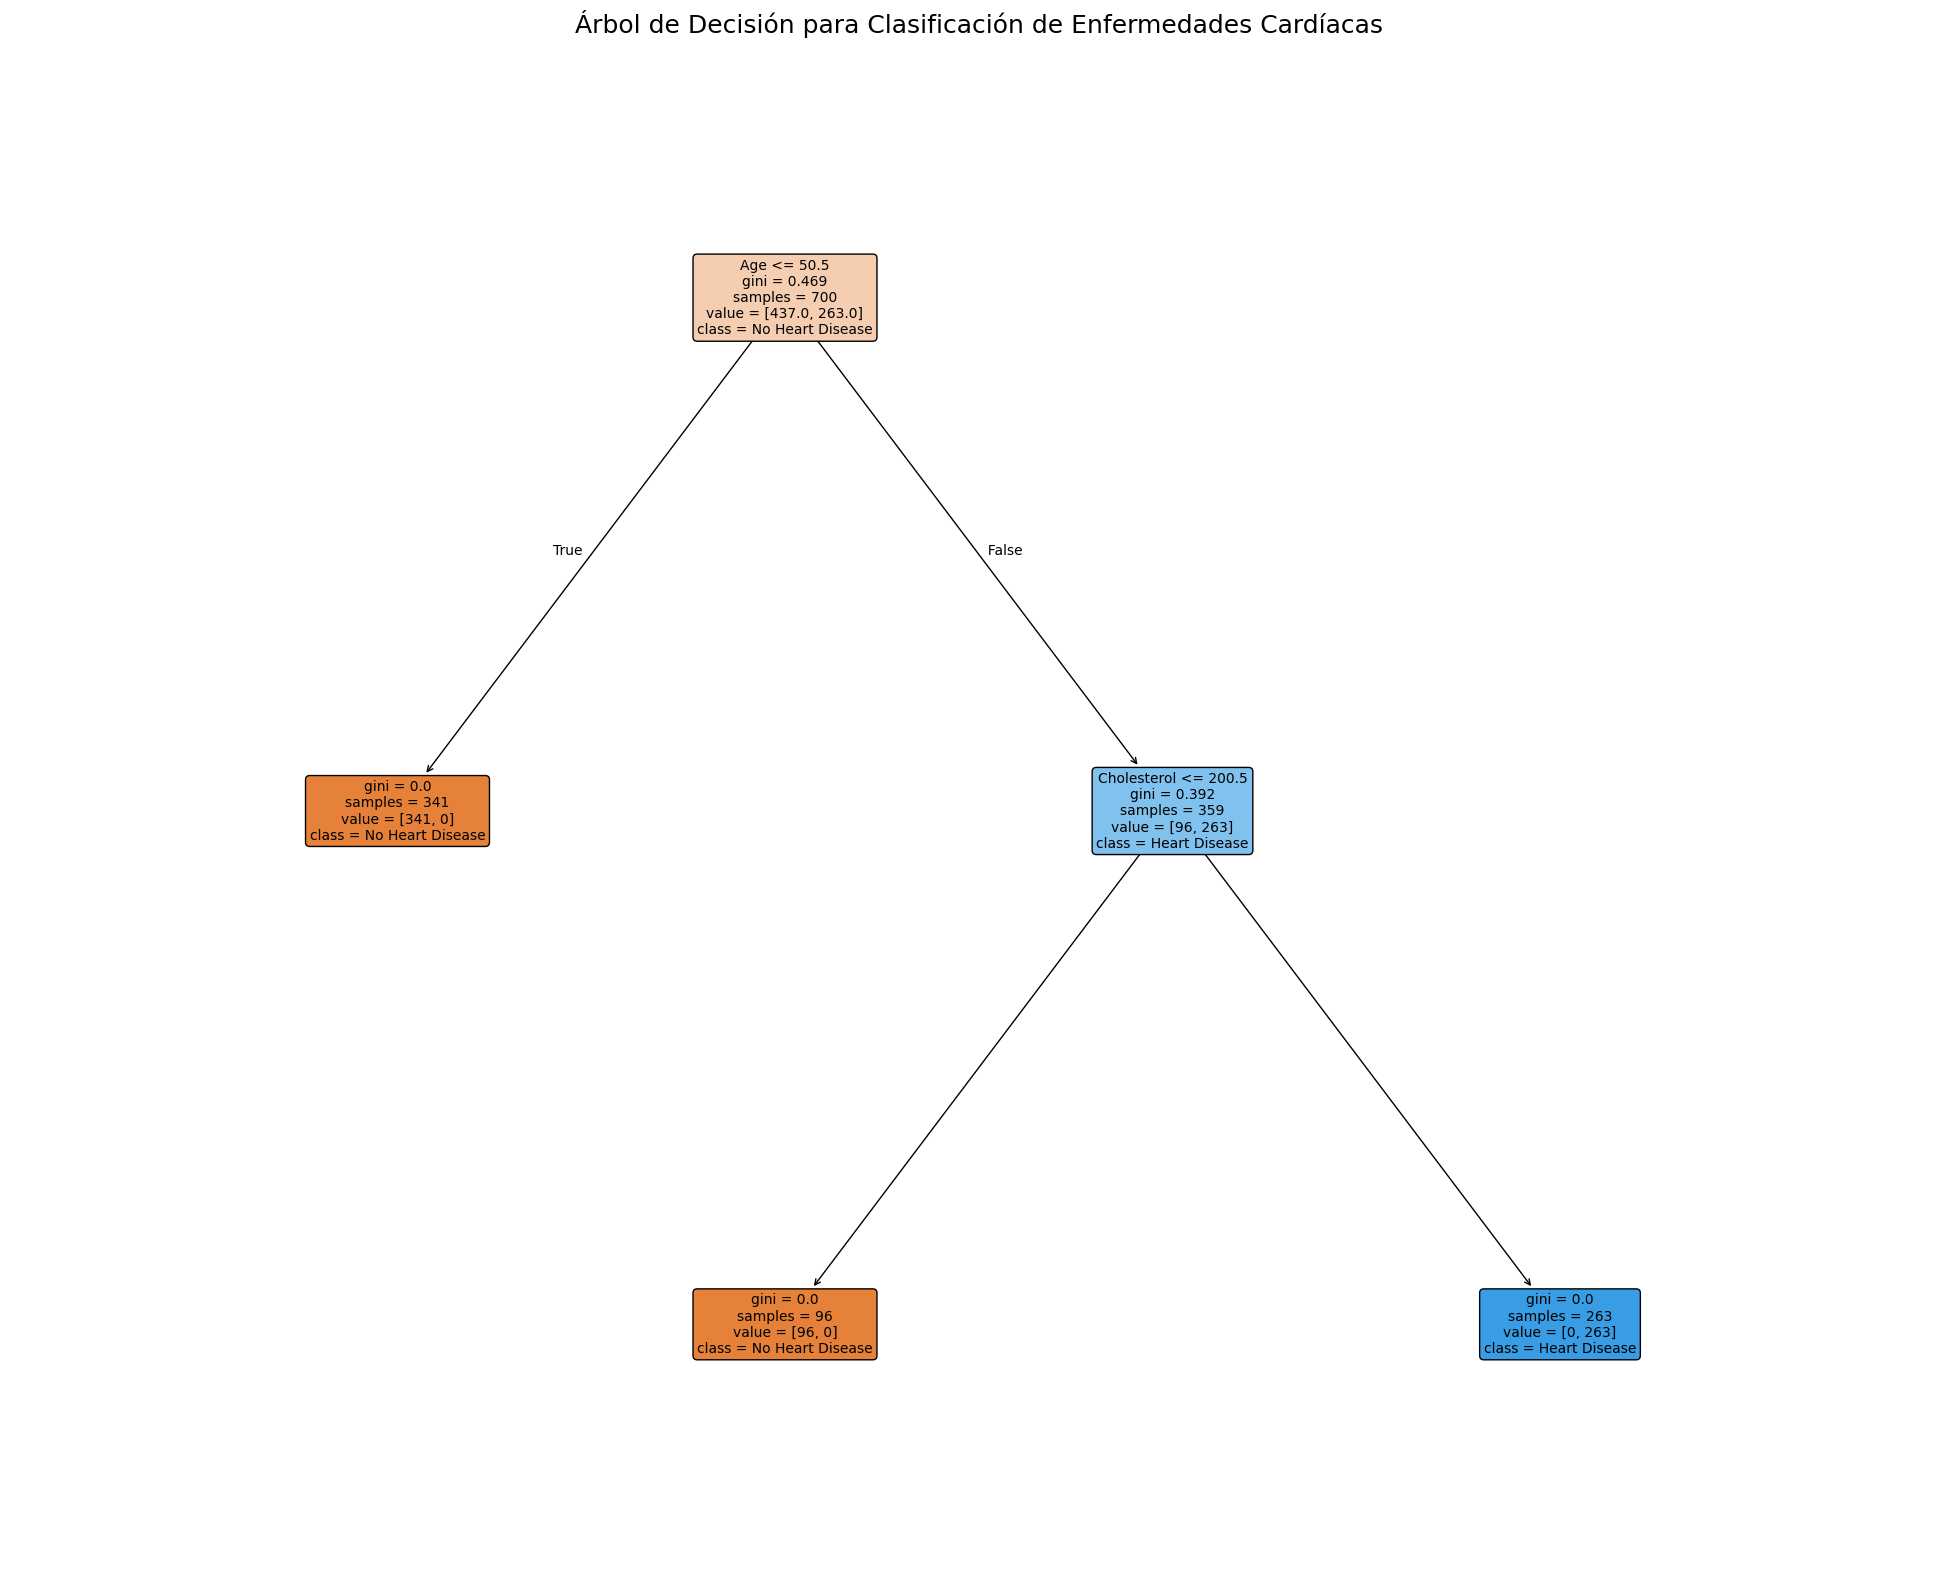

In [62]:
plt.figure(figsize=(25, 20))
plot_tree(dt_classifier,
          feature_names=X_clf.columns.tolist(),
          class_names=['No Heart Disease', 'Heart Disease'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión para Clasificación de Enfermedades Cardíacas', fontsize=18)
plt.show()

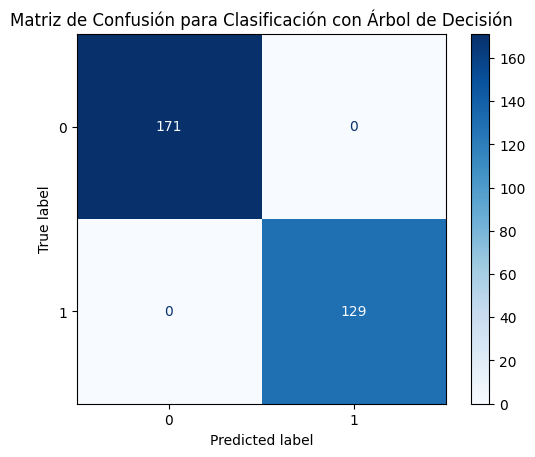

In [59]:
# Generar la matriz de confusión para Árbol de Decisión Clasificación
cm_dt = confusion_matrix(y_test_clf, y_pred_dt_clf)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_classifier.classes_)
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión para Clasificación con Árbol de Decisión')
plt.show()

### 3.2 Regresión con Árbol de Decisión

Ahora, usaremos un Árbol de Decisión para predecir `Cholesterol`.

In [61]:
# Usaremos los mismos X_reg e y_reg definidos anteriormente
# X_train_reg, X_test_reg, y_train_reg, y_test_reg

# Inicializar y entrenar el Regresor de Árbol de Decisión
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train_reg, y_train_reg)

# Realizar predicciones
y_pred_dt_reg = dt_regressor.predict(X_test_reg)

# Evaluar el modelo
print("### Resultados de Regresión con Árbol de Decisión ###")
print(f"Error Absoluto Medio (MAE): {mean_absolute_error(y_test_reg, y_pred_dt_reg):.2f}")
print(f"R-cuadrado (R2): {r2_score(y_test_reg, y_pred_dt_reg):.2f}")

### Resultados de Regresión con Árbol de Decisión ###
Error Absoluto Medio (MAE): 67.31
R-cuadrado (R2): -1.07
